In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import kaleido

In [23]:
import os

print(os.getcwd())

C:\Users\hp\bluestock_mf_capstone\data\raw


In [3]:
os.chdir(r"C:\Users\hp\bluestock_mf_capstone\data\raw")

In [4]:
print(os.getcwd())

C:\Users\hp\bluestock_mf_capstone\data\raw


In [5]:
fund_master = pd.read_csv("01_fund_master.csv")
nav_history = pd.read_csv("02_nav_history.csv")
aum = pd.read_csv("03_aum_by_fund_house.csv")
sip = pd.read_csv("04_monthly_sip_inflows.csv")
category = pd.read_csv("05_category_inflows.csv")
folios = pd.read_csv("06_industry_folio_count.csv")
performance = pd.read_csv("07_scheme_performance.csv")
transactions = pd.read_csv("08_investor_transactions.csv")
holdings = pd.read_csv("09_portfolio_holdings.csv")

In [6]:
# Convert dates:
nav_history['date'] = pd.to_datetime(nav_history['date'])
aum['date'] = pd.to_datetime(aum['date'])
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

## NAV Trend Analysis 

In [7]:
# Identify top 10 schemes by AUM
top10 = performance.nlargest(10,'aum_crore')['amfi_code']

In [8]:
top10

35    148568
21    120842
17    118634
37    149322
32    102886
29    101207
11    120504
16    118633
14    120507
30    101208
Name: amfi_code, dtype: int64

In [9]:
# Filter NAV data
nav_top10 = nav_history[
    nav_history['amfi_code'].isin(top10)
]

In [10]:
nav_top10

,amfi_code,date,nav
12650,120504,2022-01-03,60.1474
12651,120504,2022-01-04,59.4577
12652,120504,2022-01-05,60.2855
12653,120504,2022-01-06,60.5202
12654,120504,2022-01-07,60.6373
...,...,...,...
43695,149322,2026-05-25,615.8714
43696,149322,2026-05-26,616.0989
43697,149322,2026-05-27,609.8571
43698,149322,2026-05-28,604.9862


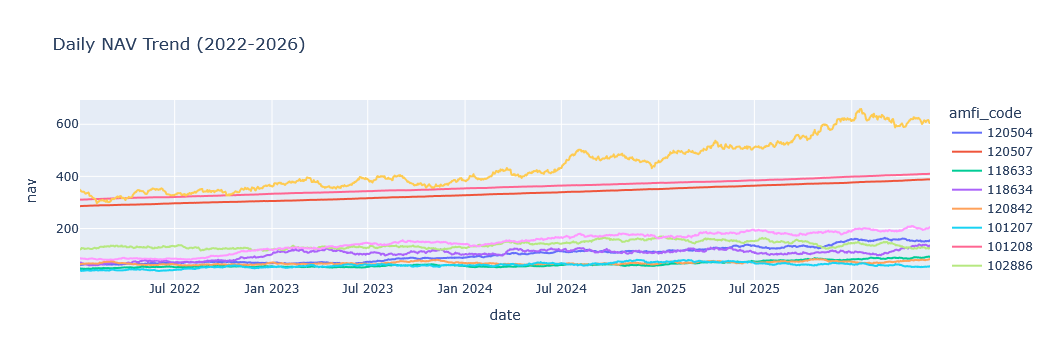

In [24]:
# Plotly chart
fig = px.line(
    nav_top10,
    x='date',
    y='nav',
    color='amfi_code',
    title='Daily NAV Trend (2022-2026)'
)

fig.show()

# AUM Growth

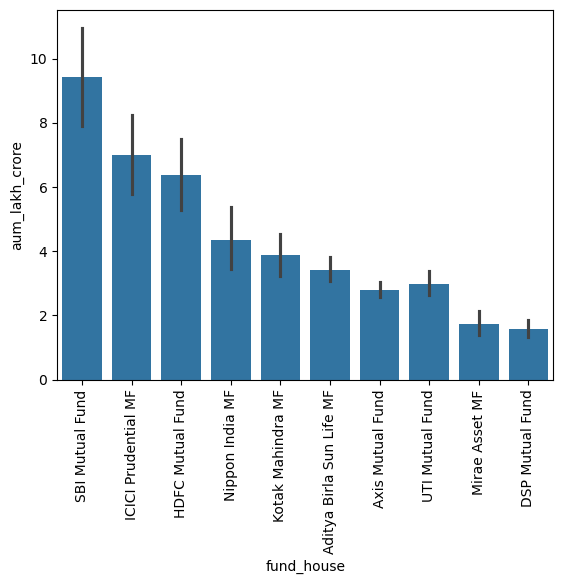

In [12]:
sns.barplot(
    data=aum,
    x='fund_house',
    y='aum_lakh_crore'
)

plt.xticks(rotation=90)
plt.show()

# SIP Trend

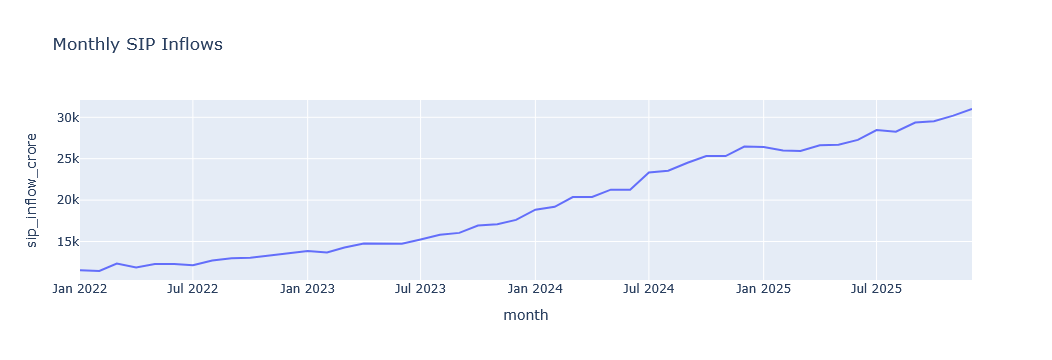

In [27]:
sip['month'] = pd.to_datetime(sip['month'])

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflows'
)

fig.show()

## Category Inflow Heatmap

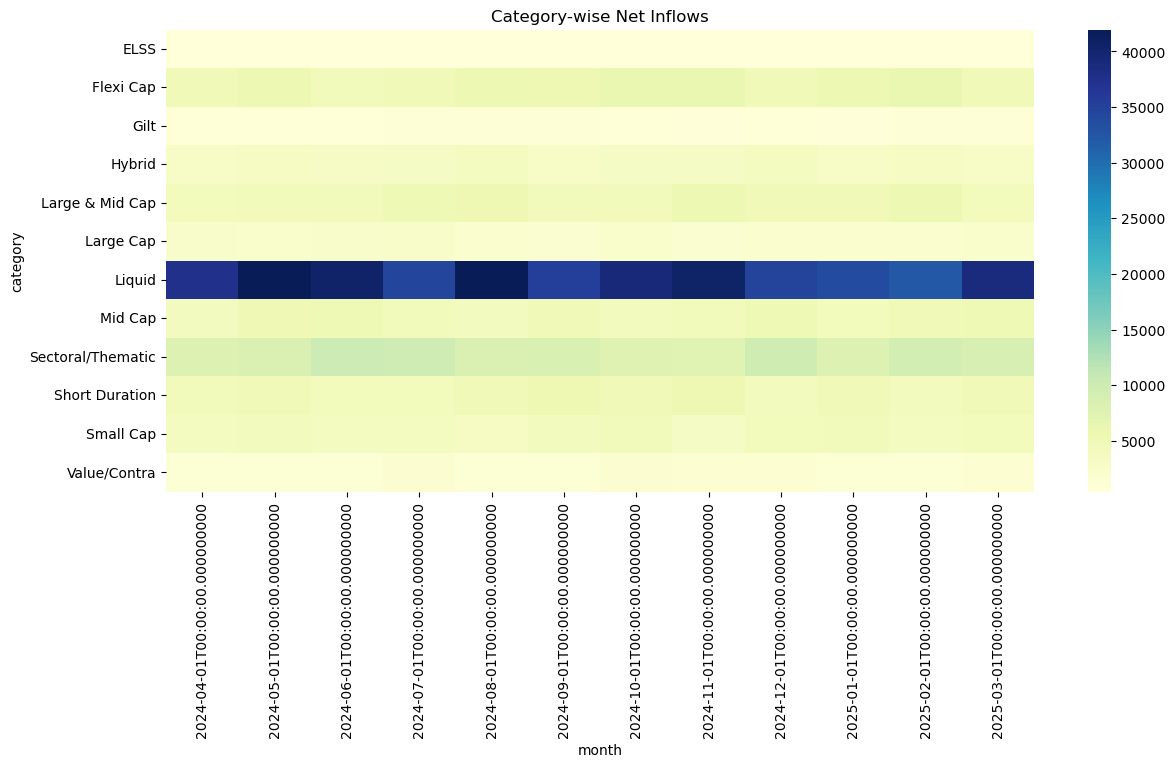

In [14]:
category['month'] = pd.to_datetime(category['month'])

heatmap_data = category.pivot_table(
    index='category',
    columns='month',
    values='net_inflow_crore',
    aggfunc='sum'
)

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, cmap='YlGnBu')

plt.title('Category-wise Net Inflows')
plt.show()

## Investor Demographics

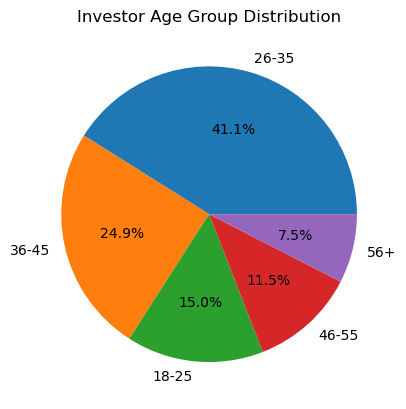

In [15]:
# Age Group Distribution
transactions['age_group'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Investor Age Group Distribution')
plt.ylabel('')
plt.show()

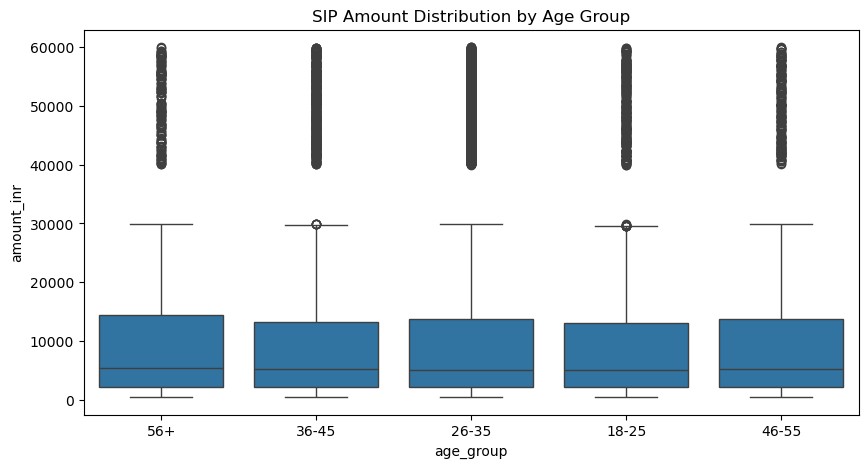

In [16]:
# SIP Amount Box Plot by Age Group
sip_txn = transactions[
    transactions['transaction_type'] == 'SIP'
]

plt.figure(figsize=(10,5))

sns.boxplot(
    data=sip_txn,
    x='age_group',
    y='amount_inr'
)

plt.title('SIP Amount Distribution by Age Group')
plt.show()

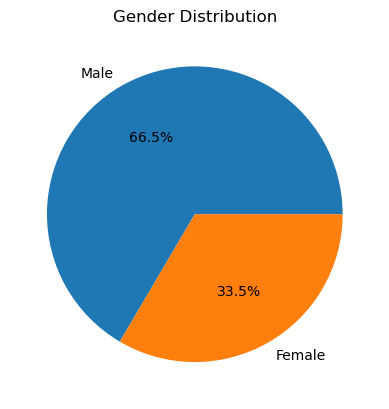

In [17]:
# Gender Split
transactions['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

## Geographic Distribution

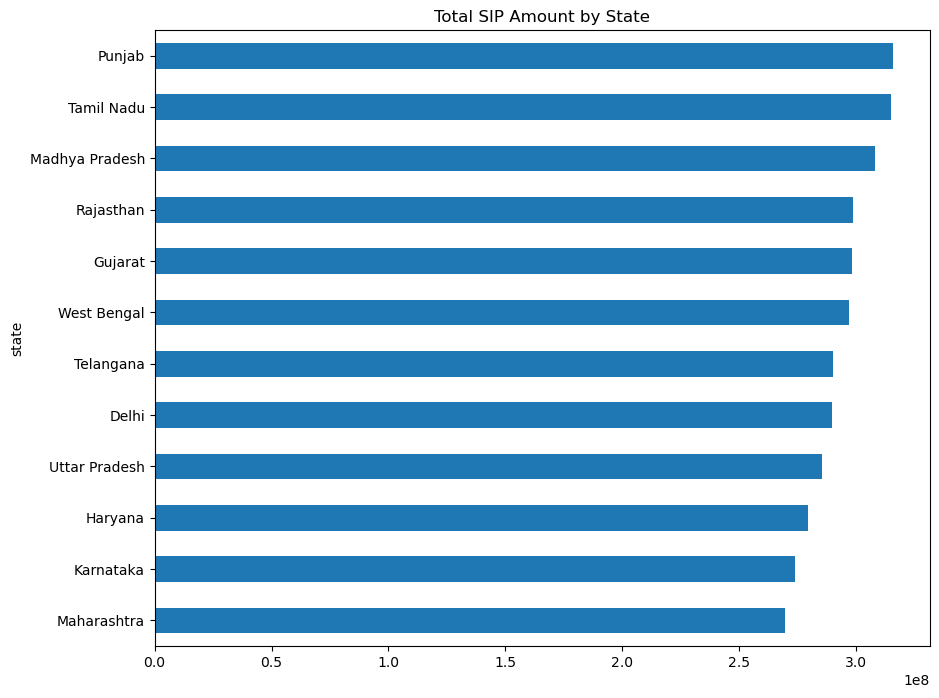

In [18]:
# SIP Amount by State
state_sip = transactions.groupby(
    'state'
)['amount_inr'].sum().sort_values()

plt.figure(figsize=(10,8))

state_sip.plot(kind='barh')

plt.title('Total SIP Amount by State')
plt.show()

## Folio Count Growth Analysis 

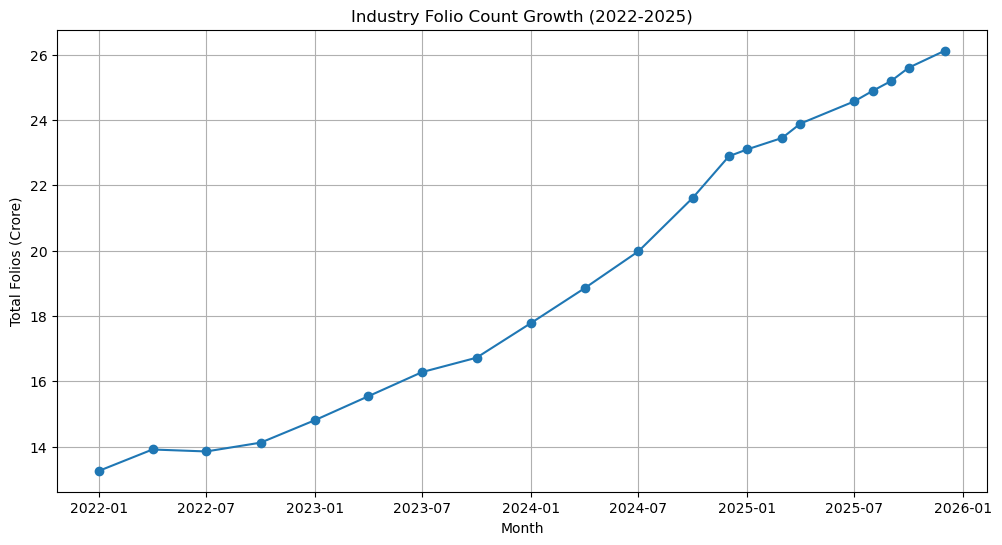

In [26]:
folios['month'] = pd.to_datetime(folios['month'])

plt.figure(figsize=(12,6))

plt.plot(
    folios['month'],
    folios['total_folios_crore'],
    marker='o'
)

plt.title('Industry Folio Count Growth (2022-2025)')
plt.xlabel('Month')
plt.ylabel('Total Folios (Crore)')
plt.grid(True)

plt.show()

## T30 vs B30

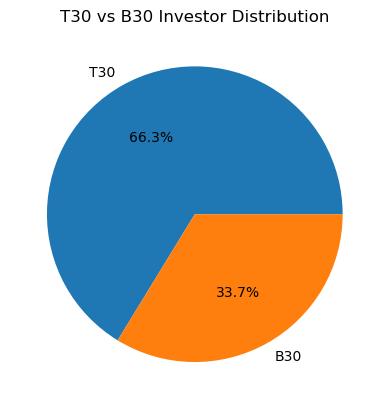

In [19]:
transactions['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('T30 vs B30 Investor Distribution')
plt.ylabel('')
plt.show()

##  NAV Return Correlation Matrix 

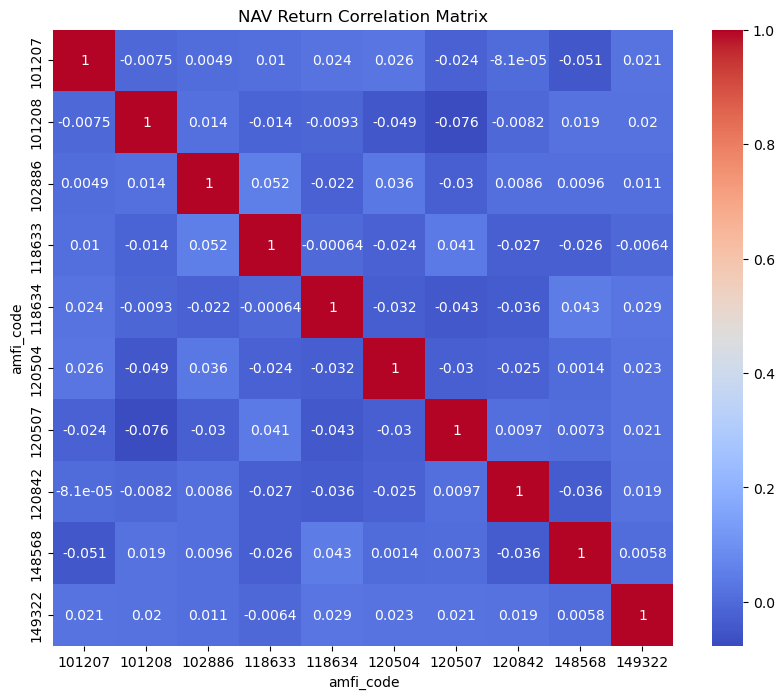

In [20]:
# Select top 10 funds by AUM
top10 = performance.nlargest(10, 'aum_crore')['amfi_code']

nav_top10 = nav_history[
    nav_history['amfi_code'].isin(top10)
]

# Create pivot table
nav_pivot = nav_top10.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

# Daily returns
returns = nav_pivot.pct_change().dropna()

# Correlation matrix
corr_matrix = returns.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm')

plt.title('NAV Return Correlation Matrix')
plt.show()

## Sector Allocation Donut Chart

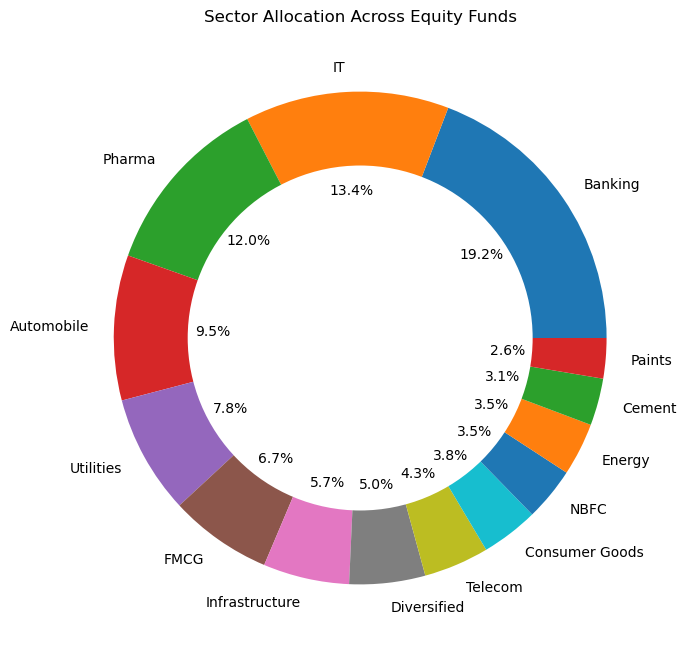

In [21]:
sector_weights = holdings.groupby(
    'sector'
)['weight_pct'].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc='white'
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Sector Allocation Across Equity Funds')
plt.show()

## Transaction Type Distribution

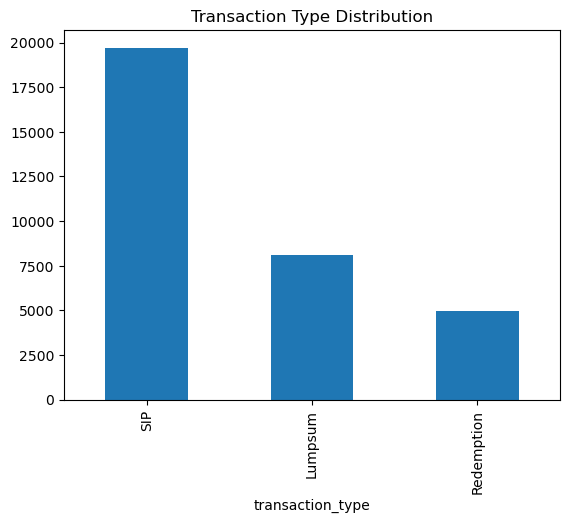

In [28]:
transactions['transaction_type'].value_counts().plot(
    kind='bar'
)

plt.title('Transaction Type Distribution')
plt.show()

## Expense Ratio vs Return

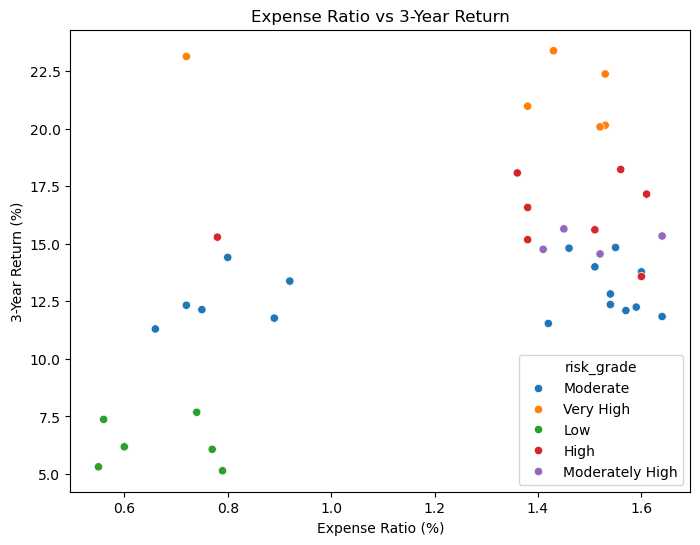

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=performance,
    x='expense_ratio_pct',
    y='return_3yr_pct',
    hue='risk_grade'
)

plt.title('Expense Ratio vs 3-Year Return')
plt.xlabel('Expense Ratio (%)')
plt.ylabel('3-Year Return (%)')

plt.show()

## Risk Category Distribution

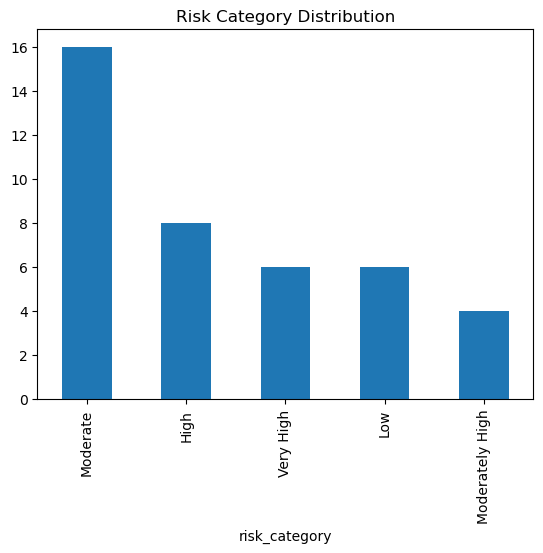

In [30]:
fund_master['risk_category'].value_counts().plot(
    kind='bar'
)

plt.title('Risk Category Distribution')
plt.show()

## Morningstar Rating Distribution

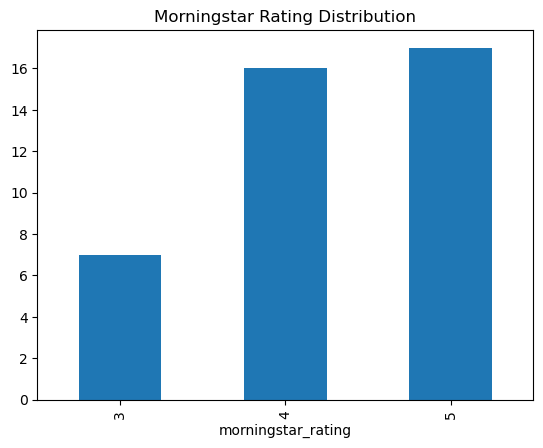

In [31]:
performance['morningstar_rating'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title('Morningstar Rating Distribution')
plt.show()

## Returns by Risk Grade 

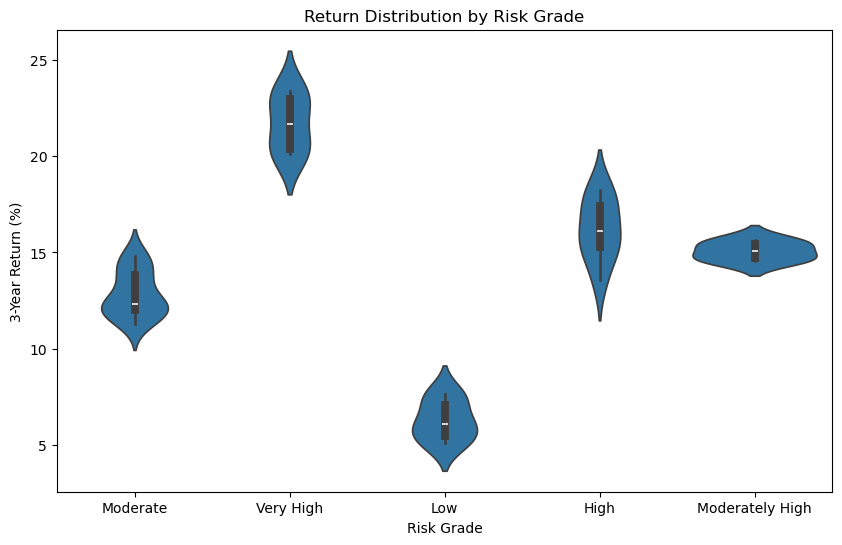

In [33]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=performance,
    x='risk_grade',
    y='return_3yr_pct'
)

plt.title('Return Distribution by Risk Grade')
plt.xlabel('Risk Grade')
plt.ylabel('3-Year Return (%)')

plt.show()

## Cumulative SIP Growth

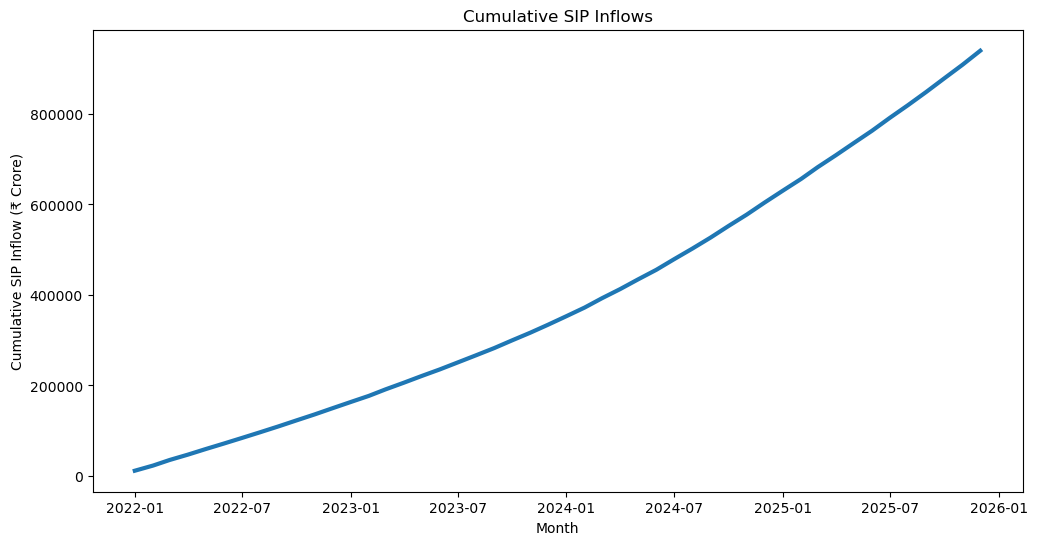

In [34]:
sip['cumulative_sip'] = sip['sip_inflow_crore'].cumsum()

plt.figure(figsize=(12,6))

plt.plot(
    pd.to_datetime(sip['month']),
    sip['cumulative_sip'],
    linewidth=3
)

plt.title('Cumulative SIP Inflows')
plt.xlabel('Month')
plt.ylabel('Cumulative SIP Inflow (₹ Crore)')

plt.show()

# 10 EDA Insights

## NAV Growth Trend
### Most mutual fund schemes exhibited consistent NAV growth between 2022 and 2026, with scheme 120842 significantly outperforming peers and crossing NAV 600 by 2026.
#### Supporting Chart: Daily NAV Trend (2022–2026)

## Market Resilience
### Despite short-term volatility during 2023–2024, all major schemes maintained a positive long-term growth trajectory, demonstrating resilience to market corrections.

#### Supporting Chart: Daily NAV Trend (2022–2026)

## Fund House Dominance
### SBI Mutual Fund emerged as the largest fund house by AUM, maintaining a substantial lead over ICICI Prudential and HDFC Mutual Fund.

#### Supporting Chart: AUM Growth by Fund House

## Rising SIP Participation
### Monthly SIP inflows increased steadily from approximately ₹12,000 crore in 2022 to over ₹28,000 crore by 2025, indicating growing retail investor participation.

#### Supporting Chart: Monthly SIP Inflows

## Category Preference
### Liquid Funds consistently attracted the highest net inflows across the observed period, reflecting investor preference for liquidity and lower-risk investment options.

#### Supporting Chart: Category-wise Net Inflows Heatmap

## Young Investors Drive Growth
### Investors aged 26–35 constitute the largest investor segment at 41.1%, making young professionals the primary contributors to mutual fund investments.

#### Supporting Chart: Investor Age Group Distribution

## Consistent SIP Behaviour Across Ages
### SIP investment amounts show similar median values across age groups, suggesting disciplined investment behaviour irrespective of investor age.

#### Supporting Chart: SIP Amount Distribution by Age Group

## Gender Participation Gap
### Male investors account for 66.5% of the investor base compared to 33.5% female participation, indicating a significant gender gap in mutual fund investing.

#### Supporting Chart: Gender Distribution

## Urban Market Concentration
### T30 cities contribute 66.3% of investor participation, nearly double the contribution of B30 cities, highlighting stronger mutual fund penetration in metropolitan regions.

#### Supporting Chart: T30 vs B30 Investor Distribution

## Sector Allocation Concentration
### Banking represents the largest portfolio allocation at 19.2%, followed by IT (13.4%) and Pharma (12.0%), indicating a strong concentration in sectors with established earnings potential.

#### Supporting Chart: Sector Allocation Across Equity Funds

## Folio Count Growth Analysis
### Total mutual fund folios increased from approximately 13.26 crore in January 2022 to 26.12 crore in December 2025, indicating strong growth in investor participation and increasing adoption of mutual fund investments in India.

#### Supporting Chart: Industry Folio Count Growth (2022–2025)

## Expense Ratio vs Return Analysis
### No strong linear relationship is observed between expense ratio and 3-year returns, suggesting that higher fund expenses do not necessarily guarantee superior performance.

#### Supporting Chart: Expense Ratio vs 3-Year Return

## Return Distribution by Risk Grade
### Higher-risk funds exhibit a wider distribution of returns, indicating greater return potential but also increased performance variability.

#### Supporting Chart: Return Distribution by Risk Grade

## Cumulative SIP Growth
### Cumulative SIP inflows show uninterrupted growth throughout the analysis period, reflecting rising investor confidence and increasing adoption of systematic investing.

#### Supporting Chart: Cumulative SIP Inflows